In [1]:
import os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, KFold
from sklearn.preprocessing   import LabelEncoder, RobustScaler
from sklearn.metrics         import (mean_absolute_error, mean_squared_error,
                                     r2_score, mean_absolute_percentage_error)
from sklearn.linear_model    import Ridge
from sklearn.ensemble        import RandomForestRegressor, GradientBoostingRegressor
from xgboost                 import XGBRegressor
from lightgbm                import LGBMRegressor
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import statsmodels.api as sm

plt.style.use("seaborn-v0_8-whitegrid")
SEED = 42
np.random.seed(SEED)


In [2]:
# SECTION 1 — DATA LOADING
# =============================================================================
print("="*60)
print("SECTION 1: DATA LOADING")
print("="*60)

DATA_PATH = "/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv"

df_raw = pd.read_csv(DATA_PATH)
print(f"Shape  : {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")
print(df_raw.head(3))


SECTION 1: DATA LOADING
Shape  : (2640, 12)
Columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']
   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)              12207  
1          249.46    Official (Quarter)               7640  
2          605.59  Interpolated (Month

In [3]:
# SECTION 2 — PREPROCESSING
# =============================================================================
print("\n" + "="*60)
print("SECTION 2: PREPROCESSING")
print("="*60)

df = df_raw.copy()
df["Year"]  = df["Year"].astype(int)
df["Month"] = df["Month"].astype(int)
df.drop_duplicates(inplace=True)

numeric_cols = ["Estimated_Deliveries", "Production_Units", "Avg_Price_USD",
                "Battery_Capacity_kWh", "Range_km", "CO2_Saved_tons", "Charging_Stations"]

def cap_outliers(s):
    q1, q3 = s.quantile(0.01), s.quantile(0.99)
    return s.clip(q1 - 3*(q3-q1), q3 + 3*(q3-q1))

for col in numeric_cols:
    df[col] = cap_outliers(df[col])

print(f"Missing values:\n{df.isnull().sum()}")
print(f"Clean shape: {df.shape}")



SECTION 2: PREPROCESSING
Missing values:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64
Clean shape: (2640, 12)



SECTION 3: EDA


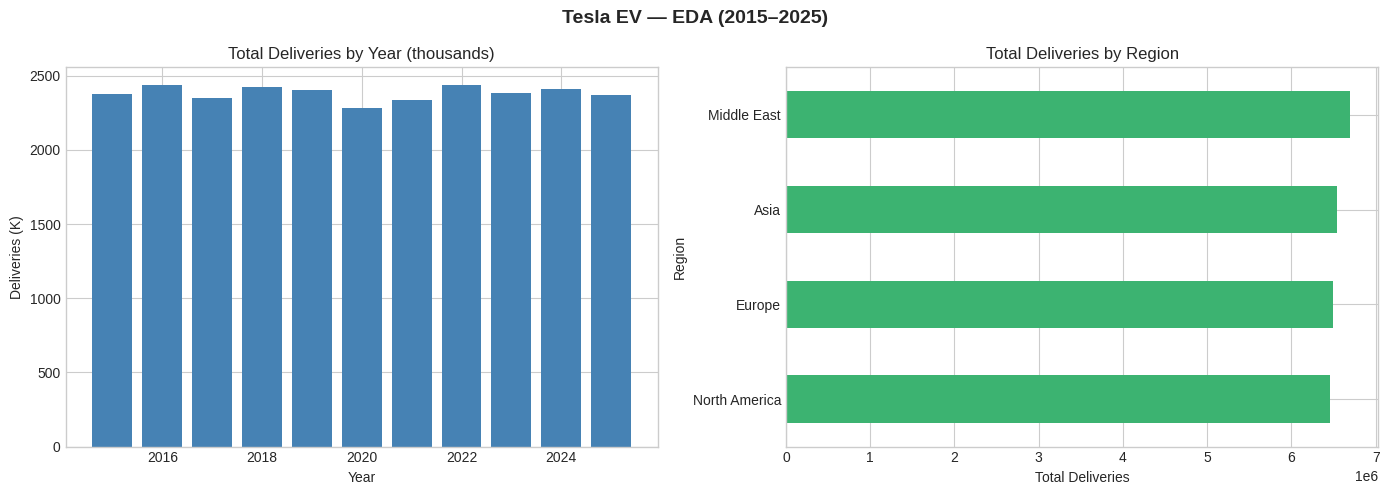

Saved → eda_plots.png


In [4]:
# SECTION 3 — EDA  (2 plots)
# =============================================================================
print("\n" + "="*60)
print("SECTION 3: EDA")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

yearly = df.groupby("Year")["Estimated_Deliveries"].sum()
axes[0].bar(yearly.index, yearly.values / 1e3, color="steelblue")
axes[0].set_title("Total Deliveries by Year (thousands)")
axes[0].set_xlabel("Year"); axes[0].set_ylabel("Deliveries (K)")

df.groupby("Region")["Estimated_Deliveries"].sum().sort_values().plot(
    kind="barh", ax=axes[1], color="mediumseagreen")
axes[1].set_title("Total Deliveries by Region")
axes[1].set_xlabel("Total Deliveries")

plt.suptitle("Tesla EV — EDA (2015–2025)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_plots.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → eda_plots.png")


In [5]:
# SECTION 4 — FEATURE ENGINEERING
# =============================================================================
print("\n" + "="*60)
print("SECTION 4: FEATURE ENGINEERING")
print("="*60)

df["Date"]    = pd.to_datetime(df[["Year", "Month"]].assign(day=1))
df["Quarter"] = df["Date"].dt.quarter

df["Price_per_Range"]       = df["Avg_Price_USD"]        / (df["Range_km"]             + 1)
df["Price_per_kWh"]         = df["Avg_Price_USD"]        / (df["Battery_Capacity_kWh"] + 1)
df["Delivery_Rate"]         = df["Estimated_Deliveries"] / (df["Production_Units"]      + 1)
df["CO2_per_Delivery"]      = df["CO2_Saved_tons"]       / (df["Estimated_Deliveries"]  + 1)
df["Stations_per_Delivery"] = df["Charging_Stations"]    / (df["Estimated_Deliveries"]  + 1)
df["Range_per_kWh"]         = df["Range_km"]             / (df["Battery_Capacity_kWh"] + 1)
df["Month_sin"]             = np.sin(2 * np.pi * df["Month"] / 12)
df["Month_cos"]             = np.cos(2 * np.pi * df["Month"] / 12)
df["Year_norm"]             = (df["Year"] - df["Year"].min()) / (df["Year"].max() - df["Year"].min())

df.sort_values(["Region", "Model", "Year", "Month"], inplace=True)
GRP = ["Region", "Model"]

for lag in [1, 2, 3]:
    df[f"Delivery_Lag_{lag}"] = df.groupby(GRP)["Estimated_Deliveries"].shift(lag)
    df[f"Price_Lag_{lag}"]    = df.groupby(GRP)["Avg_Price_USD"].shift(lag)

df["Delivery_Roll3"] = df.groupby(GRP)["Estimated_Deliveries"].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean())
df["Price_Roll3"]    = df.groupby(GRP)["Avg_Price_USD"].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean())

le = LabelEncoder()
df["Region_enc"] = le.fit_transform(df["Region"])
df["Model_enc"]  = le.fit_transform(df["Model"])
df["Source_enc"] = le.fit_transform(df["Source_Type"])

print(f"Done. Shape: {df.shape}")




SECTION 4: FEATURE ENGINEERING
Done. Shape: (2640, 34)


In [6]:
# SECTION 5 — REGRESSION MODELLING
# =============================================================================
print("\n" + "="*60)
print("SECTION 5: REGRESSION MODELLING — TARGET: Avg_Price_USD")
print("="*60)

FEATURES = [
    "Year", "Month", "Quarter", "Year_norm", "Month_sin", "Month_cos",
    "Region_enc", "Model_enc", "Source_enc",
    "Battery_Capacity_kWh", "Range_km", "Charging_Stations",
    "Estimated_Deliveries", "Production_Units", "CO2_Saved_tons",
    "Price_per_Range", "Price_per_kWh", "Delivery_Rate",
    "CO2_per_Delivery", "Stations_per_Delivery", "Range_per_kWh",
    "Delivery_Lag_1", "Delivery_Lag_2", "Delivery_Lag_3",
    "Price_Lag_1",    "Price_Lag_2",    "Price_Lag_3",
    "Delivery_Roll3", "Price_Roll3",
]
TARGET = "Avg_Price_USD"

ml_df = df[FEATURES + [TARGET]].dropna()
X = ml_df[FEATURES];  y = ml_df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

scaler = RobustScaler()
X_tr_s = scaler.fit_transform(X_train)
X_te_s = scaler.transform(X_test)

results = []

def score(name, model, Xtr, ytr, Xte, yte):
    model.fit(Xtr, ytr)
    p    = model.predict(Xte)
    r2   = r2_score(yte, p)
    mae  = mean_absolute_error(yte, p)
    rmse = np.sqrt(mean_squared_error(yte, p))
    mape = mean_absolute_percentage_error(yte, p) * 100
    print(f"  {name:<28} R²={r2:.4f}  MAE={mae:,.0f}  RMSE={rmse:,.0f}  MAPE={mape:.2f}%")
    return {"Model": name, "R2": r2, "MAE": mae, "RMSE": rmse, "MAPE": mape,
            "fitted": model, "preds": p}

results.append(score("Ridge",
    Ridge(alpha=10),
    X_tr_s, y_train, X_te_s, y_test))

results.append(score("Random Forest",
    RandomForestRegressor(n_estimators=100, max_depth=10, random_state=SEED, n_jobs=-1),
    X_train, y_train, X_test, y_test))

results.append(score("Gradient Boosting",
    GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=SEED),
    X_train, y_train, X_test, y_test))

results.append(score("XGBoost",
    XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5,
                 subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1,
                 random_state=SEED, verbosity=0),
    X_train, y_train, X_test, y_test))

results.append(score("LightGBM",
    LGBMRegressor(n_estimators=200, learning_rate=0.05, max_depth=5,
                  num_leaves=31, subsample=0.8, reg_alpha=0.1,
                  random_state=SEED, verbose=-1),
    X_train, y_train, X_test, y_test))



SECTION 5: REGRESSION MODELLING — TARGET: Avg_Price_USD
  Ridge                        R²=0.8970  MAE=5,266  RMSE=6,502  MAPE=6.27%
  Random Forest                R²=0.9985  MAE=319  RMSE=795  MAPE=0.40%
  Gradient Boosting            R²=0.9979  MAE=691  RMSE=933  MAPE=0.86%
  XGBoost                      R²=0.9986  MAE=564  RMSE=747  MAPE=0.69%
  LightGBM                     R²=0.9989  MAE=498  RMSE=686  MAPE=0.62%


In [7]:
# SECTION 6 — HYPERPARAMETER TUNING  (RandomizedSearchCV — fast)
# =============================================================================
print("\n" + "="*60)
print("SECTION 6: HYPERPARAMETER TUNING  (3-fold, 10 iters)")
print("="*60)

cv_kf = KFold(n_splits=3, shuffle=True, random_state=SEED)

# XGBoost tuning
rs_xgb = RandomizedSearchCV(
    XGBRegressor(reg_alpha=0.1, reg_lambda=1.0, random_state=SEED, verbosity=0),
    {"n_estimators": [150, 200, 300], "learning_rate": [0.03, 0.05, 0.08],
     "max_depth": [4, 5, 6], "subsample": [0.8, 0.9]},
    n_iter=10, cv=cv_kf, scoring="r2", n_jobs=-1, random_state=SEED, verbose=0)
rs_xgb.fit(X_train, y_train)
best_xgb  = rs_xgb.best_estimator_
preds_xgb = best_xgb.predict(X_test)
r2_xgb    = r2_score(y_test, preds_xgb)
mae_xgb   = mean_absolute_error(y_test, preds_xgb)
rmse_xgb  = np.sqrt(mean_squared_error(y_test, preds_xgb))
mape_xgb  = mean_absolute_percentage_error(y_test, preds_xgb) * 100
print(f"  Best XGB : {rs_xgb.best_params_}")
print(f"  XGBoost (Tuned)              R²={r2_xgb:.4f}  MAE={mae_xgb:,.0f}  RMSE={rmse_xgb:,.0f}  MAPE={mape_xgb:.2f}%")
results.append({"Model": "XGBoost (Tuned)", "R2": r2_xgb, "MAE": mae_xgb,
                "RMSE": rmse_xgb, "MAPE": mape_xgb, "fitted": best_xgb, "preds": preds_xgb})

# LightGBM tuning
rs_lgb = RandomizedSearchCV(
    LGBMRegressor(reg_alpha=0.1, reg_lambda=1.0, random_state=SEED, verbose=-1),
    {"n_estimators": [150, 200, 300], "learning_rate": [0.03, 0.05, 0.08],
     "max_depth": [4, 5, 6], "num_leaves": [31, 63]},
    n_iter=10, cv=cv_kf, scoring="r2", n_jobs=-1, random_state=SEED, verbose=0)
rs_lgb.fit(X_train, y_train)
best_lgb  = rs_lgb.best_estimator_
preds_lgb = best_lgb.predict(X_test)
r2_lgb    = r2_score(y_test, preds_lgb)
mae_lgb   = mean_absolute_error(y_test, preds_lgb)
rmse_lgb  = np.sqrt(mean_squared_error(y_test, preds_lgb))
mape_lgb  = mean_absolute_percentage_error(y_test, preds_lgb) * 100
print(f"  Best LGB : {rs_lgb.best_params_}")
print(f"  LightGBM (Tuned)             R²={r2_lgb:.4f}  MAE={mae_lgb:,.0f}  RMSE={rmse_lgb:,.0f}  MAPE={mape_lgb:.2f}%")
results.append({"Model": "LightGBM (Tuned)", "R2": r2_lgb, "MAE": mae_lgb,
                "RMSE": rmse_lgb, "MAPE": mape_lgb, "fitted": best_lgb, "preds": preds_lgb})

# Ensemble blend
blend   = 0.5 * preds_xgb + 0.5 * preds_lgb
r2_bl   = r2_score(y_test, blend)
mae_bl  = mean_absolute_error(y_test, blend)
rmse_bl = np.sqrt(mean_squared_error(y_test, blend))
mape_bl = mean_absolute_percentage_error(y_test, blend) * 100
print(f"  Blend XGB+LGB                R²={r2_bl:.4f}  MAE={mae_bl:,.0f}  RMSE={rmse_bl:,.0f}  MAPE={mape_bl:.2f}%")
results.append({"Model": "Blend XGB+LGB", "R2": r2_bl, "MAE": mae_bl,
                "RMSE": rmse_bl, "MAPE": mape_bl, "fitted": None, "preds": blend})


SECTION 6: HYPERPARAMETER TUNING  (3-fold, 10 iters)
  Best XGB : {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.05}
  XGBoost (Tuned)              R²=0.9992  MAE=386  RMSE=571  MAPE=0.48%
  Best LGB : {'num_leaves': 63, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.03}
  LightGBM (Tuned)             R²=0.9989  MAE=435  RMSE=685  MAPE=0.55%
  Blend XGB+LGB                R²=0.9992  MAE=351  RMSE=556  MAPE=0.44%



SECTION 7: FEATURE IMPORTANCE
CO2_per_Delivery        0.348753
Price_per_kWh           0.287329
Battery_Capacity_kWh    0.190885
Range_km                0.119100
Price_per_Range         0.051676
Estimated_Deliveries    0.000330
Delivery_Roll3          0.000279
Range_per_kWh           0.000209
Charging_Stations       0.000119
Production_Units        0.000112


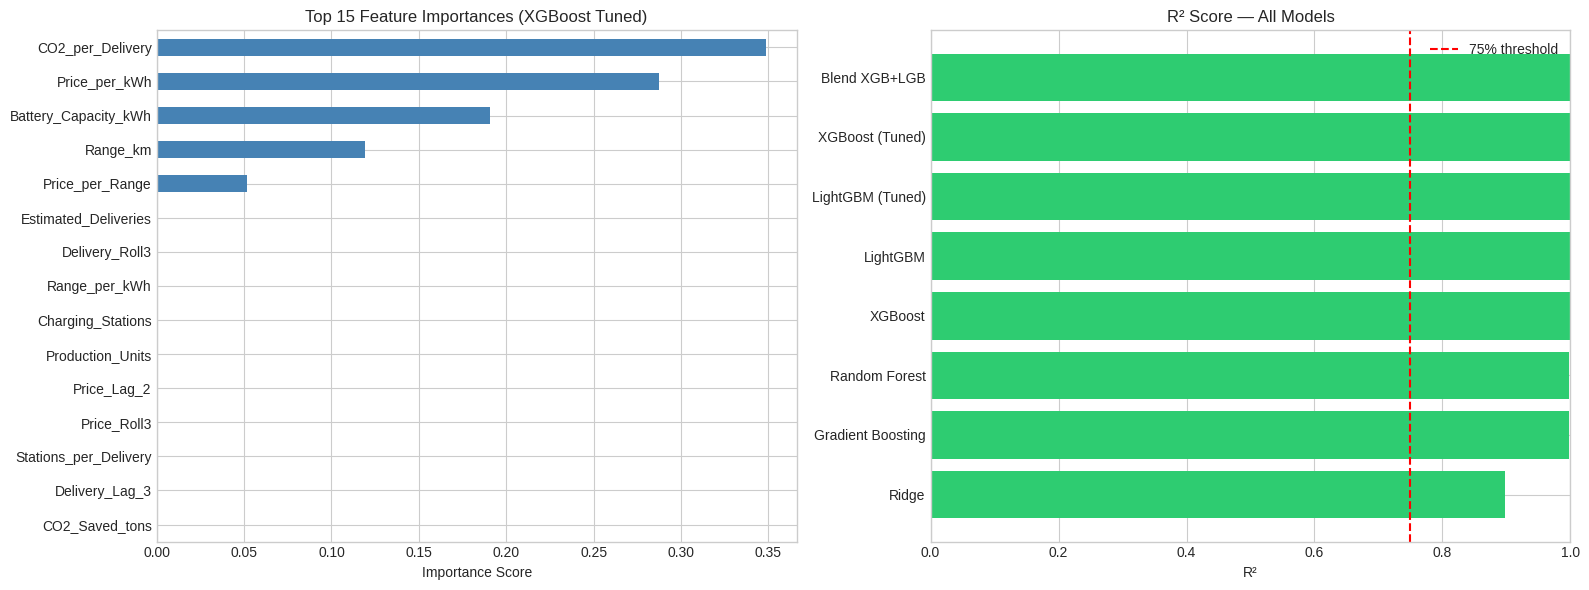

Saved → model_comparison.png


In [8]:
# SECTION 7 — FEATURE IMPORTANCE + MODEL COMPARISON
# =============================================================================
print("\n" + "="*60)
print("SECTION 7: FEATURE IMPORTANCE")
print("="*60)

fi = pd.Series(best_xgb.feature_importances_, index=FEATURES).sort_values(ascending=False)
print(fi.head(10).to_string())

res_df = (pd.DataFrame([{k: v for k, v in r.items() if k not in ("fitted", "preds")}
                         for r in results])
            .sort_values("R2", ascending=True))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fi.head(15).plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].invert_yaxis()
axes[0].set_title("Top 15 Feature Importances (XGBoost Tuned)")
axes[0].set_xlabel("Importance Score")

colors = ["#2ecc71" if v >= 0.75 else "#e74c3c" for v in res_df["R2"]]
axes[1].barh(res_df["Model"], res_df["R2"], color=colors)
axes[1].axvline(0.75, color="red", linestyle="--", label="75% threshold")
axes[1].set_title("R² Score — All Models"); axes[1].set_xlabel("R²")
axes[1].legend(); axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → model_comparison.png")



SECTION 8: REGRESSION DIAGNOSTICS


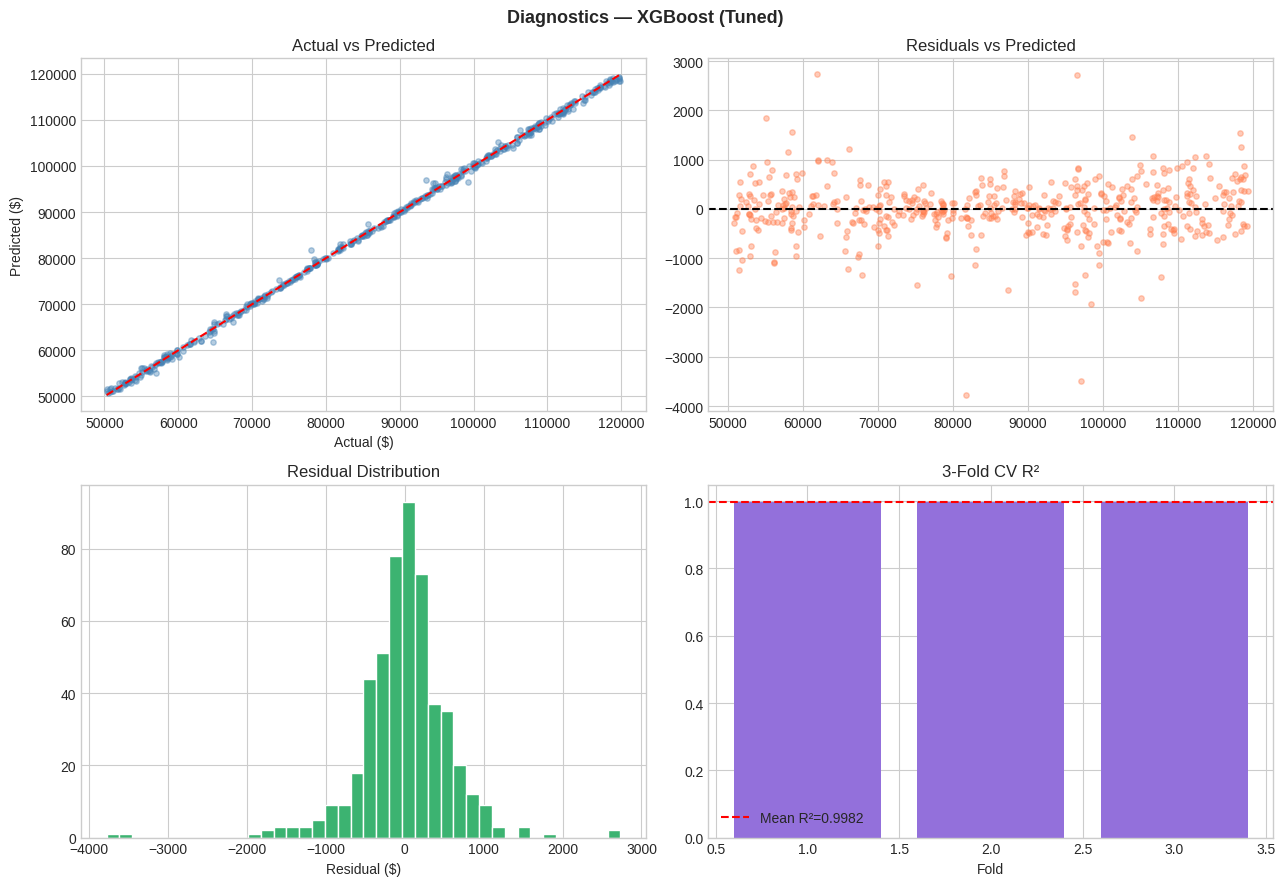

CV R²: [0.9986 0.9985 0.9974]  |  Mean: 0.9982
Saved → diagnostics.png


In [9]:
# SECTION 8 — DIAGNOSTICS
# =============================================================================
print("\n" + "="*60)
print("SECTION 8: REGRESSION DIAGNOSTICS")
print("="*60)

residuals = y_test.values - preds_xgb
cv_scores = cross_val_score(best_xgb, X_train, y_train, cv=3, scoring="r2")

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].scatter(y_test, preds_xgb, alpha=0.4, color="steelblue", s=15)
lims = [min(y_test.min(), preds_xgb.min()), max(y_test.max(), preds_xgb.max())]
axes[0, 0].plot(lims, lims, "r--")
axes[0, 0].set_title("Actual vs Predicted")
axes[0, 0].set_xlabel("Actual ($)"); axes[0, 0].set_ylabel("Predicted ($)")

axes[0, 1].scatter(preds_xgb, residuals, alpha=0.4, color="coral", s=15)
axes[0, 1].axhline(0, color="black", linestyle="--")
axes[0, 1].set_title("Residuals vs Predicted")

axes[1, 0].hist(residuals, bins=40, color="mediumseagreen", edgecolor="white")
axes[1, 0].set_title("Residual Distribution"); axes[1, 0].set_xlabel("Residual ($)")

axes[1, 1].bar(range(1, len(cv_scores)+1), cv_scores, color="mediumpurple")
axes[1, 1].axhline(cv_scores.mean(), color="red", linestyle="--",
                    label=f"Mean R²={cv_scores.mean():.4f}")
axes[1, 1].set_title("3-Fold CV R²"); axes[1, 1].set_xlabel("Fold"); axes[1, 1].legend()

plt.suptitle("Diagnostics — XGBoost (Tuned)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("diagnostics.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"CV R²: {cv_scores.round(4)}  |  Mean: {cv_scores.mean():.4f}")
print("Saved → diagnostics.png")


In [10]:
# SECTION 9 — TIME SERIES FORECASTING
# =============================================================================
print("\n" + "="*60)
print("SECTION 9: TIME SERIES FORECASTING")
print("="*60)

ts = (df.groupby(["Year", "Month"])["Estimated_Deliveries"].sum()
        .reset_index()
        .assign(Date=lambda x: pd.to_datetime(x[["Year", "Month"]].assign(day=1)))
        .set_index("Date").sort_index()["Estimated_Deliveries"])

ts_train, ts_test = ts.iloc[:-12], ts.iloc[-12:]
print(f"Train: {ts_train.index[0].date()} → {ts_train.index[-1].date()}")
print(f"Test : {ts_test.index[0].date()}  → {ts_test.index[-1].date()}")

# Holt-Winters
hw      = ExponentialSmoothing(ts_train, trend="add", seasonal="add",
                                seasonal_periods=12).fit(optimized=True)
hw_pred = hw.forecast(12)
hw_r2   = r2_score(ts_test, hw_pred)
hw_mape = mean_absolute_percentage_error(ts_test, hw_pred) * 100
print(f"  Holt-Winters  → R²={hw_r2:.4f}  MAPE={hw_mape:.2f}%")

# SARIMA
try:
    sarima      = sm.tsa.statespace.SARIMAX(ts_train, order=(1, 1, 1),
                    seasonal_order=(1, 1, 1, 12)).fit(disp=False)
    sarima_pred = sarima.forecast(12)
    sar_r2      = r2_score(ts_test, sarima_pred)
    sar_mape    = mean_absolute_percentage_error(ts_test, sarima_pred) * 100
    print(f"  SARIMA        → R²={sar_r2:.4f}  MAPE={sar_mape:.2f}%")
except Exception as e:
    print(f"  SARIMA skipped: {e}")
    sarima_pred, sar_r2, sar_mape = hw_pred, hw_r2, hw_mape

# XGBoost TS
def make_lag_features(series, lags=6):
    d = pd.DataFrame({"y": series})
    for i in range(1, lags + 1):
        d[f"lag_{i}"] = d["y"].shift(i)
    d["month_sin"] = np.sin(2 * np.pi * d.index.month / 12)
    d["month_cos"] = np.cos(2 * np.pi * d.index.month / 12)
    d["year"]      = d.index.year
    return d.dropna()

lag_df    = make_lag_features(ts, lags=6)
fc_cols   = [c for c in lag_df.columns if c != "y"]
split_idx = len(lag_df) - 12
Xts_tr, Xts_te = lag_df[fc_cols].iloc[:split_idx], lag_df[fc_cols].iloc[split_idx:]
yts_tr, yts_te = lag_df["y"].iloc[:split_idx],      lag_df["y"].iloc[split_idx:]

xgb_ts = XGBRegressor(n_estimators=150, learning_rate=0.05, max_depth=4,
                       verbosity=0, random_state=SEED)
xgb_ts.fit(Xts_tr, yts_tr)
xgb_ts_pred = xgb_ts.predict(Xts_te)
xgb_ts_r2   = r2_score(yts_te, xgb_ts_pred)
xgb_ts_mape = mean_absolute_percentage_error(yts_te, xgb_ts_pred) * 100
print(f"  XGBoost TS    → R²={xgb_ts_r2:.4f}  MAPE={xgb_ts_mape:.2f}%")


SECTION 9: TIME SERIES FORECASTING
Train: 2015-01-01 → 2024-12-01
Test : 2025-01-01  → 2025-12-01
  Holt-Winters  → R²=-0.1626  MAPE=5.51%


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


  SARIMA        → R²=-1.5849  MAPE=8.15%
  XGBoost TS    → R²=-0.8653  MAPE=7.05%



SECTION 10: FORECAST PLOT


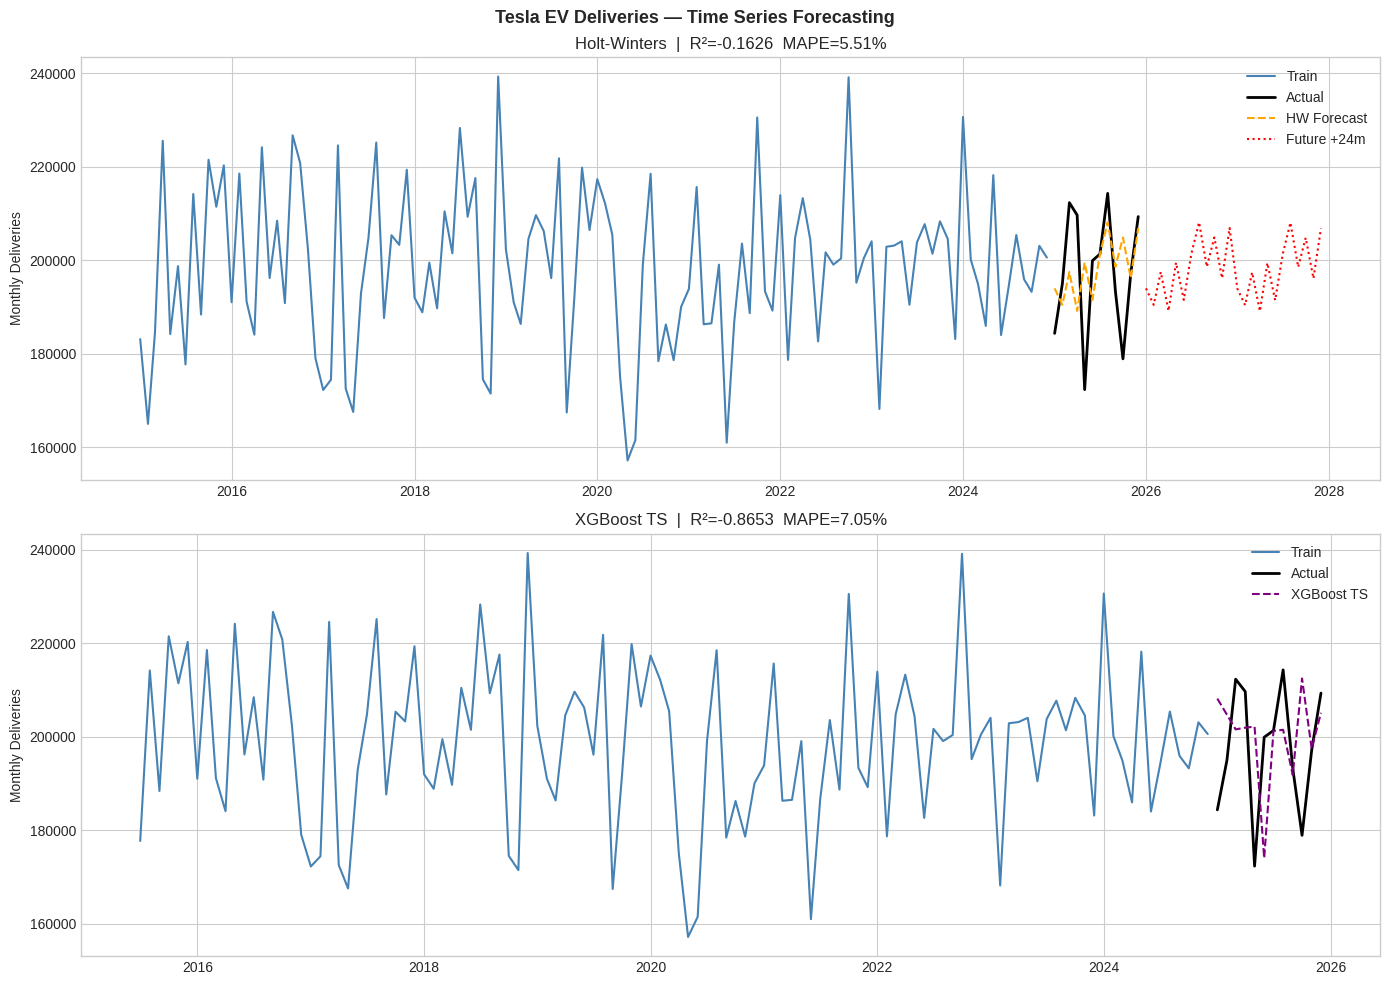

Saved → ts_forecast.png


In [11]:
# SECTION 10 — FORECAST PLOT + 24-MONTH FUTURE
# =============================================================================
print("\n" + "="*60)
print("SECTION 10: FORECAST PLOT")
print("="*60)

future_hw       = hw.forecast(24)
future_hw.index = pd.date_range(ts_test.index[-1] + pd.DateOffset(months=1),
                                 periods=24, freq="MS")

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(ts_train.index, ts_train.values, label="Train",        color="steelblue")
axes[0].plot(ts_test.index,  ts_test.values,  label="Actual",       color="black",  lw=2)
axes[0].plot(ts_test.index,  hw_pred.values,  label="HW Forecast",  color="orange", linestyle="--")
axes[0].plot(future_hw.index, future_hw.values, label="Future +24m",color="red",    linestyle=":")
axes[0].set_title(f"Holt-Winters  |  R²={hw_r2:.4f}  MAPE={hw_mape:.2f}%")
axes[0].legend(); axes[0].set_ylabel("Monthly Deliveries")

axes[1].plot(yts_tr.index, yts_tr.values, label="Train",        color="steelblue")
axes[1].plot(yts_te.index, yts_te.values, label="Actual",       color="black",  lw=2)
axes[1].plot(yts_te.index, xgb_ts_pred,   label="XGBoost TS",  color="purple", linestyle="--")
axes[1].set_title(f"XGBoost TS  |  R²={xgb_ts_r2:.4f}  MAPE={xgb_ts_mape:.2f}%")
axes[1].legend(); axes[1].set_ylabel("Monthly Deliveries")

plt.suptitle("Tesla EV Deliveries — Time Series Forecasting", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("ts_forecast.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → ts_forecast.png")


In [12]:
# SECTION 11 — FINAL LEADERBOARD
# =============================================================================
print("\n" + "="*60)
print("SECTION 11: FINAL LEADERBOARD")
print("="*60)

summary = (pd.DataFrame([{k: v for k, v in r.items() if k not in ("fitted", "preds")}
                          for r in results])
             .sort_values("R2", ascending=False).reset_index(drop=True))
summary["R2"]        = summary["R2"].round(4)
summary["MAE"]       = summary["MAE"].round(0)
summary["RMSE"]      = summary["RMSE"].round(0)
summary["MAPE"]      = summary["MAPE"].round(2)
summary["Beats 75%"] = summary["R2"].apply(lambda x: "✓" if x >= 0.75 else "✗")
print(summary.to_string(index=False))
summary.to_csv("results_summary.csv", index=False)

best = summary.iloc[0]
print(f"\n  BEST MODEL : {best['Model']}")
print(f"    R²={best['R2']:.4f}  |  MAE=${best['MAE']:,.0f}  |  RMSE=${best['RMSE']:,.0f}  |  MAPE={best['MAPE']:.2f}%")
print(f"    {' TARGET MET: R² ≥ 75%' if best['R2'] >= 0.75 else '  R² below 75%'}")
print("\nOutputs: eda_plots.png | model_comparison.png | diagnostics.png | ts_forecast.png | results_summary.csv")
print("\n Pipeline complete")



SECTION 11: FINAL LEADERBOARD
            Model     R2    MAE   RMSE  MAPE Beats 75%
    Blend XGB+LGB 0.9992  351.0  556.0  0.44         ✓
  XGBoost (Tuned) 0.9992  386.0  571.0  0.48         ✓
 LightGBM (Tuned) 0.9989  435.0  685.0  0.55         ✓
         LightGBM 0.9989  498.0  686.0  0.62         ✓
          XGBoost 0.9986  564.0  747.0  0.69         ✓
    Random Forest 0.9985  319.0  795.0  0.40         ✓
Gradient Boosting 0.9979  691.0  933.0  0.86         ✓
            Ridge 0.8970 5266.0 6502.0  6.27         ✓

  BEST MODEL : Blend XGB+LGB
    R²=0.9992  |  MAE=$351  |  RMSE=$556  |  MAPE=0.44%
     TARGET MET: R² ≥ 75%

Outputs: eda_plots.png | model_comparison.png | diagnostics.png | ts_forecast.png | results_summary.csv

 Pipeline complete
